1. Data Quality Overview
Total rows: 36,514
Total columns: 30

Missing Values:


PatientAge    34
dtype: int64


2. Target Variables Distribution

Procedure Acceptance Rate:


target_accepted
1    0.591472
0    0.408528
Name: proportion, dtype: float64


Payment within 30 days Rate:


target_paid_30d
0    0.752807
1    0.247193
Name: proportion, dtype: float64

c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

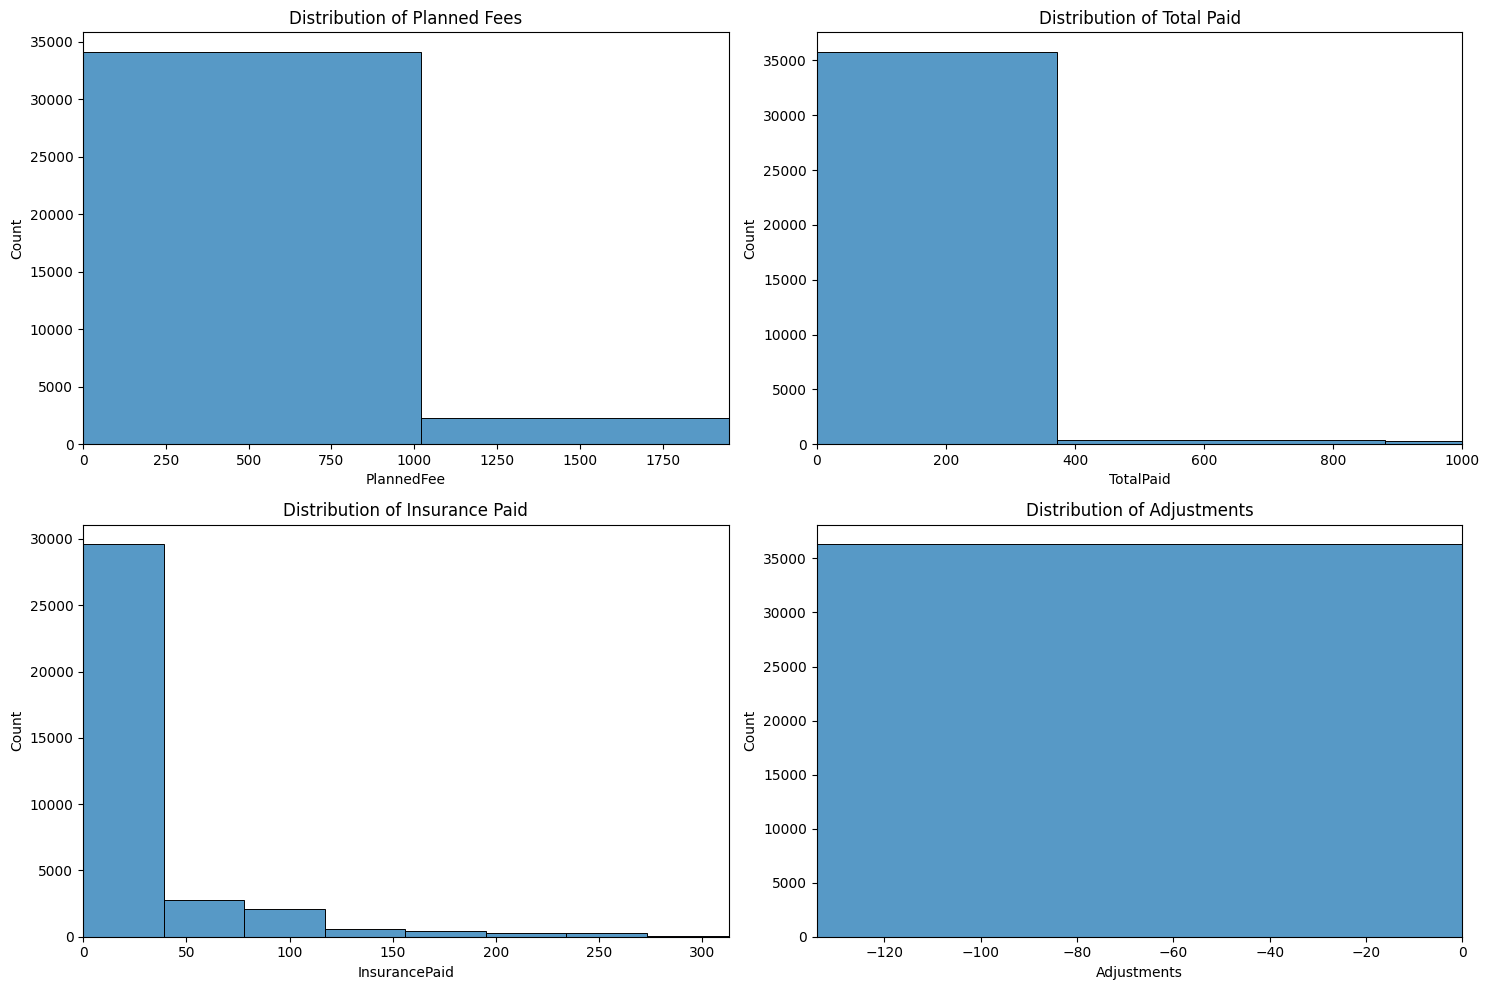


Financial Metrics Summary (excluding outliers):

PlannedFee:
Median: $76.00
IQR: $165.00
95th percentile: $1,288.00

TotalPaid:
Median: $0.00
IQR: $15.20
95th percentile: $192.43

InsurancePaid:
Median: $0.00
IQR: $0.00
95th percentile: $132.00

Adjustments:
Median: $0.00
IQR: $0.00
95th percentile: $0.00


c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


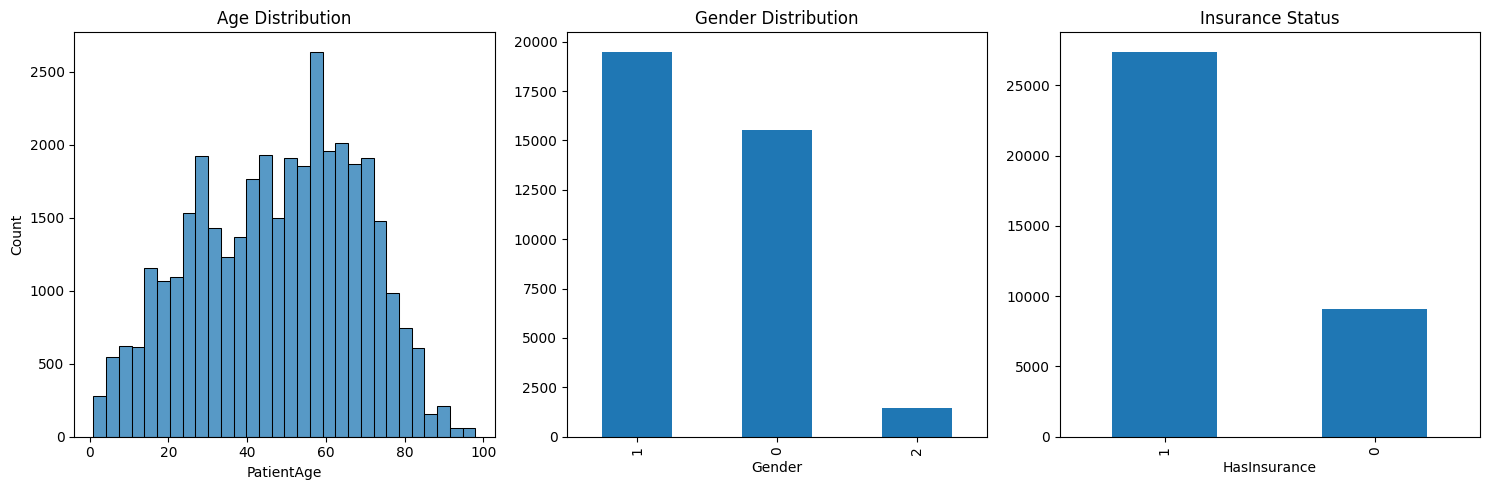

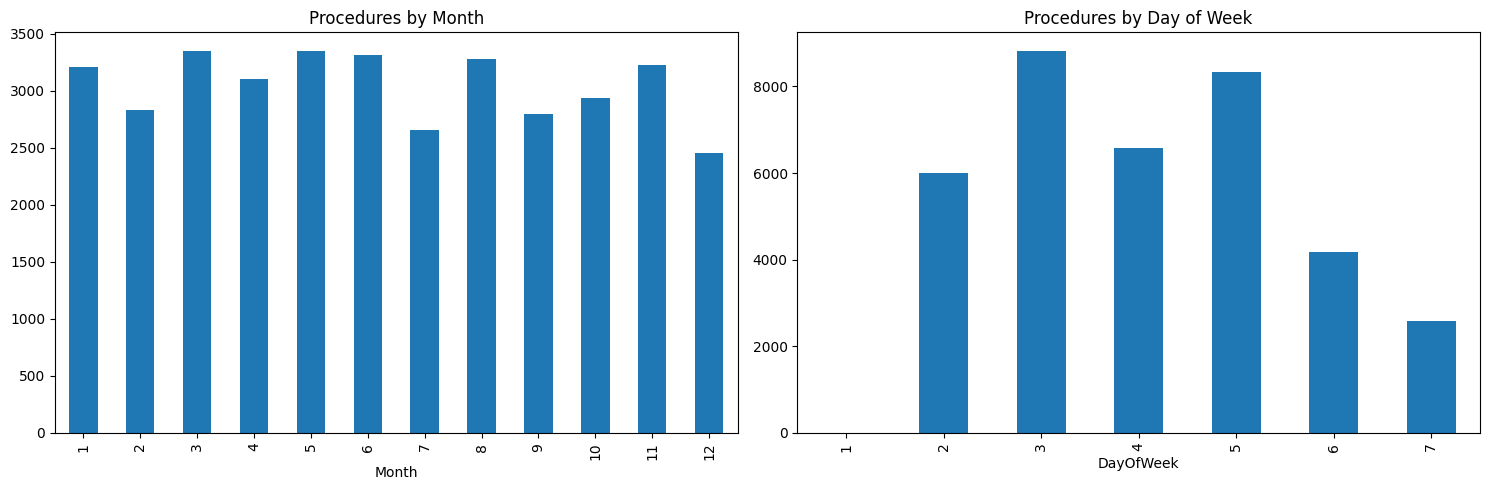


6. Financial Summary Statistics


,PlannedFee,TotalPaid,InsurancePaid,Adjustments,Balance_0_30_Days,Balance_31_60_Days,Balance_61_90_Days,Balance_Over_90_Days
count,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000
mean,219.515415,43.436409,27.527553,-11.959816,31.592128,8.994014,3.158124,31.786947
std,682.950420,224.354671,89.253518,263.939918,251.953674,71.982027,41.595323,182.824724
min,0.000000,-136.000000,0.000000,-27680.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,196.000000,15.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,51000.000000,25248.400000,1950.000000,256.000000,7101.600000,1292.800000,1306.400000,3113.000000


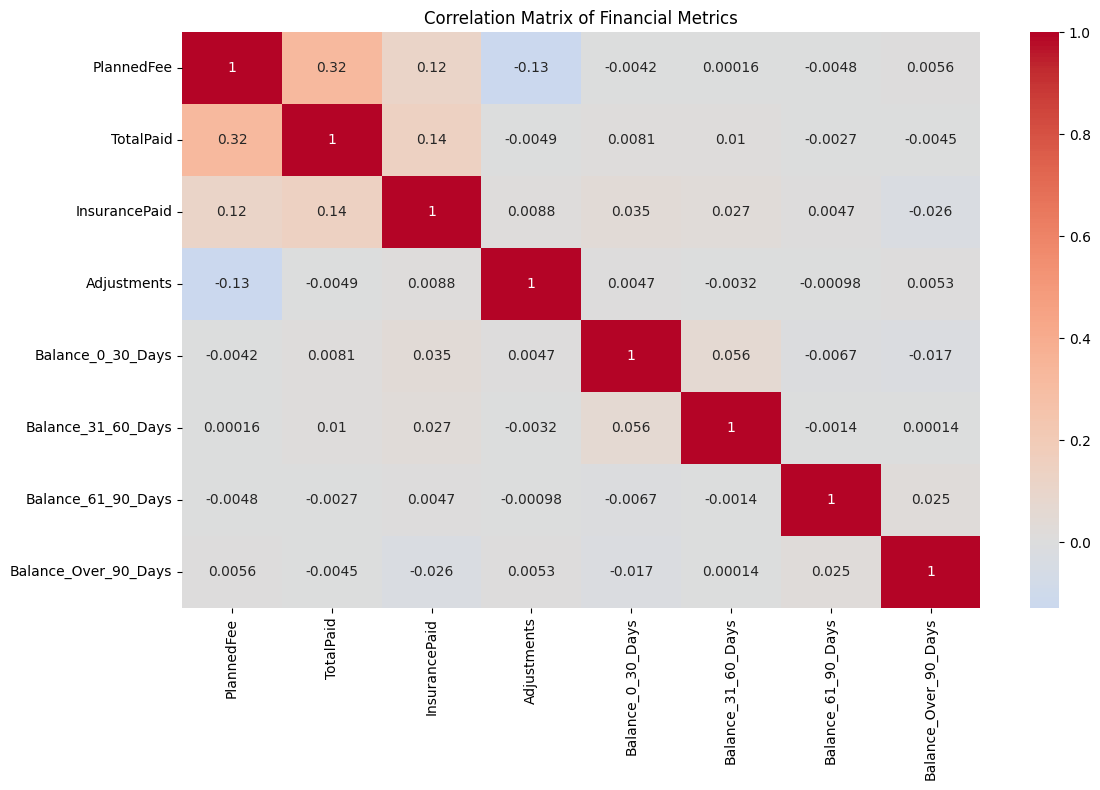


8. Procedure Categories


ProcCat
73     12069
250     6558
74      6436
81      2407
82      2346
75      2096
80      1723
77      1329
78       402
85       373
622      272
76       212
83        92
251       83
79        71
540       41
301        4
Name: count, dtype: int64


Treatment Areas:


TreatArea
0    15510
2     9434
3     7321
1     2136
7     1494
6      390
4      227
5        2
Name: count, dtype: int64


Multi-Visit Procedures:


IsMultiVisit
0    1.0
Name: proportion, dtype: float64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read the parquet file
df = pd.read_parquet('../data/processed/treatment_journey_opendental_analytics_opendentalbackup_01_03_2025.parquet')


# 1. Basic Data Quality Checks
print("1. Data Quality Overview")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")
print("\nMissing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Target Variable Distribution
print("\n2. Target Variables Distribution")
print("\nProcedure Acceptance Rate:")
display(df['target_accepted'].value_counts(normalize=True))
print("\nPayment within 30 days Rate:")
display(df['target_paid_30d'].value_counts(normalize=True))

# 3. Key Metrics Distribution with adjusted scales
plt.figure(figsize=(15, 10))

# Planned Fees
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='PlannedFee', bins=50)
plt.title('Distribution of Planned Fees')
plt.xlim(0, df['PlannedFee'].quantile(0.99))  # Limit to 99th percentile

# Total Paid
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='TotalPaid', bins=50)
plt.title('Distribution of Total Paid')
plt.xlim(0, df['TotalPaid'].quantile(0.99))

# Insurance Paid
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='InsurancePaid', bins=50)
plt.title('Distribution of Insurance Paid')
plt.xlim(0, df['InsurancePaid'].quantile(0.99))

# Adjustments
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Adjustments', bins=50)
plt.title('Distribution of Adjustments')
plt.xlim(df['Adjustments'].quantile(0.01), df['Adjustments'].quantile(0.99))  # Handle negative values

plt.tight_layout()
plt.show()

# Print summary statistics for these metrics
print("\nFinancial Metrics Summary (excluding outliers):")
financial_cols = ['PlannedFee', 'TotalPaid', 'InsurancePaid', 'Adjustments']
for col in financial_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    median = df[col].median()
    print(f"\n{col}:")
    print(f"Median: ${median:,.2f}")
    print(f"IQR: ${q3-q1:,.2f}")
    print(f"95th percentile: ${df[col].quantile(0.95):,.2f}")

# 4. Patient Demographics
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='PatientAge', bins=30)
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')

plt.subplot(1, 3, 3)
df['HasInsurance'].value_counts().plot(kind='bar')
plt.title('Insurance Status')
plt.tight_layout()
plt.show()

# 5. Temporal Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
df.groupby('Month')['ProcNum'].count().plot(kind='bar')
plt.title('Procedures by Month')

plt.subplot(1, 2, 2)
df.groupby('DayOfWeek')['ProcNum'].count().plot(kind='bar')
plt.title('Procedures by Day of Week')
plt.tight_layout()
plt.show()

# 6. Financial Metrics
print("\n6. Financial Summary Statistics")
financial_cols = ['PlannedFee', 'TotalPaid', 'InsurancePaid', 'Adjustments', 
                 'Balance_0_30_Days', 'Balance_31_60_Days', 'Balance_61_90_Days', 'Balance_Over_90_Days']
display(df[financial_cols].describe())

# 7. Correlation Analysis
plt.figure(figsize=(12, 8))
correlation_matrix = df[financial_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Financial Metrics')
plt.tight_layout()
plt.show()

# 8. Procedure Characteristics
print("\n8. Procedure Categories")
display(df['ProcCat'].value_counts())
print("\nTreatment Areas:")
display(df['TreatArea'].value_counts())
print("\nMulti-Visit Procedures:")
display(df['IsMultiVisit'].value_counts(normalize=True))



In [3]:
# Filter procedures with $0 fees
zero_fee_procedures = df[df['PlannedFee'] == 0]

# Display the count of zero-fee procedures
print(f"Total zero-fee procedures: {len(zero_fee_procedures)}")

# Analyze the types of procedures with $0 fees
print("Procedure Descriptions for $0 Fee Procedures:")
display(zero_fee_procedures['ProcDescription'].value_counts())

# Analyze target_paid_30d for $0 fee procedures
print("\nTarget Paid within 30 Days for $0 Fee Procedures:")
display(zero_fee_procedures['target_paid_30d'].value_counts(normalize=True))

Total zero-fee procedures: 7076
Procedure Descriptions for $0 Fee Procedures:


ProcDescription
cancelled appointment                                                                                                                   1914
Delivery                                                                                                                                1353
Post Op                                                                                                                                  504
TRIOS SCAN                                                                                                                               416
2D oral/facial photographic image obtained intra-orally or extra-orally                                                                  377
                                                                                                                                        ... 
pontic - porcelain fused to noble metal                                                                                                   


Target Paid within 30 Days for $0 Fee Procedures:


target_paid_30d
0    0.999293
1    0.000707
Name: proportion, dtype: float64

In [4]:
# Filter procedures with $0 fees
zero_fee_procedures = df[df['PlannedFee'] == 0]

# Further filter for procedures not paid within 30 days
not_paid_within_30d = zero_fee_procedures[zero_fee_procedures['target_paid_30d'] == 0]

# Display the count and details of these procedures
print(f"Total zero-fee procedures not paid within 30 days: {len(not_paid_within_30d)}")

# Display details of these procedures
display(not_paid_within_30d[['ProcNum', 'ProcDescription', 'ProcDate', 'PlannedFee', 'TotalPaid', 'InsurancePaid']])

Total zero-fee procedures not paid within 30 days: 7071


,ProcNum,ProcDescription,ProcDate,PlannedFee,TotalPaid,InsurancePaid
0,1102128,cancelled appointment,2023-12-30,0.0,0.0,0.0
1,1102127,cancelled appointment,2023-12-30,0.0,0.0,0.0
2,1102126,cancelled appointment,2023-12-30,0.0,0.0,0.0
3,1102125,cancelled appointment,2023-12-30,0.0,0.0,0.0
4,1102124,cancelled appointment,2023-12-30,0.0,0.0,0.0
...,...,...,...,...,...,...
36457,1056336,cancelled appointment,2023-01-02,0.0,0.0,0.0
36480,1050437,Delivery,2023-01-02,0.0,0.0,0.0
36482,1055798,TRIOS SCAN,2023-01-02,0.0,0.0,0.0
36483,1039193,Delivery,2023-01-02,0.0,0.0,0.0
